In [24]:
import pandas as pd 

df = pd.read_csv(r'C:\Users\ducli\Downloads\Unpivoted_Data.csv')

In [25]:
# ADF test
from statsmodels.tsa.stattools import adfuller
adfuller(df['Value'])

(-3.7307252140474905,
 0.003701156403118348,
 12,
 335,
 {'1%': -3.4500219858626227,
  '5%': -2.870206553997666,
  '10%': -2.571387268879483},
 583.4074799476668)

In [26]:
from statsmodels.tsa.stattools import acf
acf(df['Value'], nlags=12)


array([1.   , 0.53 , 0.3  , 0.261, 0.181, 0.109, 0.021, 0.027, 0.048,
       0.062, 0.062, 0.11 , 0.331])

In [27]:
from statsmodels.tsa.stattools import pacf
pacf(df['Value'], nlags=12)

array([ 1.   ,  0.531,  0.027,  0.129, -0.012, -0.011, -0.079,  0.043,
        0.031,  0.05 ,  0.014,  0.087,  0.331])

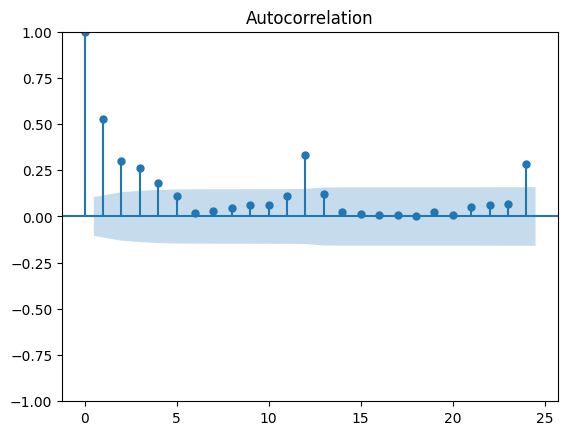

In [28]:
# plot acf
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf
plot_acf(df['Value'], lags=24)
plt.show()


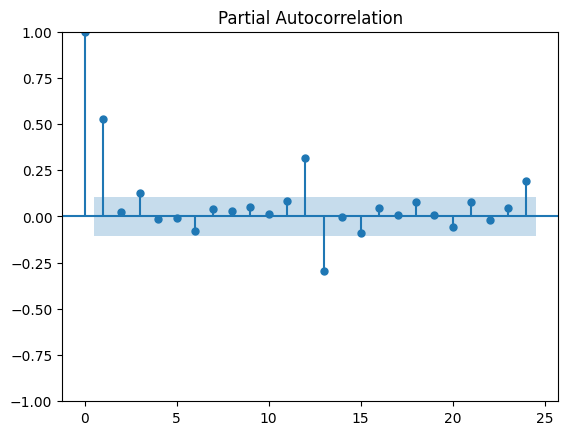

In [29]:
# pacf 
from statsmodels.graphics.tsaplots import plot_pacf
plot_pacf(df['Value'], lags=24)
plt.show()

In [31]:
# Arima
from statsmodels.tsa.arima.model import ARIMA
p = 12
d = 0 
q = 12
model = ARIMA(df['Value'], order=(p, d, q))
model_fit = model.fit()
print(model_fit.summary())


c:\Users\ducli\anaconda3\envs\crawler\lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


                               SARIMAX Results                                
Dep. Variable:                  Value   No. Observations:                  348
Model:               ARIMA(12, 0, 12)   Log Likelihood                -280.576
Date:                Thu, 15 May 2025   AIC                            613.153
Time:                        01:07:09   BIC                            713.310
Sample:                             0   HQIC                           653.027
                                - 348                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const        100.5141      0.163    617.112      0.000     100.195     100.833
ar.L1         -0.2200      0.154     -1.428      0.153      -0.522       0.082
ar.L2         -0.0677      0.162     -0.419      0.6